# [프로젝트] 민원 유형 텍스트 분류 머신러닝

---

## 프로젝트 개요

다양한 민원 내용을 신속하고 정확하게 분류하는 것은 행정의 효율성을 높이고 시민들의 만족도를 향상시키는 데 매우 중요한데요.

> "시민들이 접수한 민원을 자동으로 분류해 해당 부서로 빠르게 보낼 수 있을까?"

이번 프로젝트에서는 실제 민원 텍스트 데이터를 바탕으로, 민원 유형을 자동으로 분류하는 머신러닝 모델을 구축해 봅니다.

---

## 프로젝트 목표

- 민원 텍스트 데이터를 바탕으로 민원 유형 분류 모델 학습
- 분류 머신러닝을 위한 탐색적 데이터 분석, 데이터 전처리, 모델 선택 및 최적화 기법 등 머신러닝 기초 학습

---

## 데이터 출처

AI Hub - 민원 업무 자동화 인공지능 언어 데이터     
https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=data&dataSetSn=619

---

## 목차

1. 데이터 불러오기
2. 탐색적 데이터 분석 (EDA)
3. 데이터 전처리
4. 민원 유형 텍스트 분류 모델

---

## 1. 데이터 불러오기

이번 프로젝트에 필요한 라이브러리를 불러옵니다.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
mpl.rc('font', family='NanumGothic')

분석에 사용할 데이터는 민원 텍스트 데이터입니다.      
데이터는 `건축허가`, `경제`, `교통` 등 17가지의 민원 유형별로 구분되어 있습니다.     
우선 모든 데이터를 불러와 하나의 데이터프레임으로 합쳐줍니다.

In [2]:
doc_list = [
    'bldg_permit_57256',       # 건축허가
    'economy_15725',           # 경제
    'transport_85465',         # 교통
    'agri_livestock_9392',     # 농업_축산
    'culture_sports_tour_20224',  # 문화_체육_관광
    'health_center_20008',     # 보건소
    'welfare_20909',           # 복지
    'forestry_26264',          # 산림
    'waterworks_17215',        # 상하수도
    'tax_20500',               # 세무
    'safety_construction_93747', # 안전건설
    'sanitation_19736',        # 위생
    'automobile_295107',       # 자동차
    'ict_744',                 # 정보통신
    'land_6092',               # 토지
    'admin_23197',             # 행정
    'env_38129'                # 환경미화
]

new_rows = []

for file_name in doc_list:
    with open(f'data/{file_name}.json', 'r', encoding='utf-8') as file:
        doc = json.load(file)

    for voc in doc['documents']:
        new_rows.append({
            'text': voc['Q_refined'],
            'category': voc['labeling']['intent']['category']
        })

In [3]:
# 데이터셋 확인
df = pd.DataFrame(new_rows)
df

,text,category
0,창원시의 의창구 #@주소#에 불법건축물로 민원을 신청합니다.,건축허가
1,창원시 의창구 #@주소#에 불법건축물에 대해 빠른 처리 부탁드립니다.,건축허가
2,창원시 의창구 #@주소#에 불법건축물이 있습니다. 제발 조치해주시기 바랍니다.,건축허가
3,창원시 의창구 #@주소#에 불법건축물에 대한 법적 조치 요청합니다.,건축허가
4,경남 창원시 마산회원구 #@주소# 삼거리에 불법으로 부착된 현수막이 10개 가까이 ...,건축허가
...,...,...
769705,창원시청 노후 보일러 교체 지원금의 확인은 어느 부서로 할까요?,환경미화
769706,지금 창원시청 노후 보일러 교체시 지원금을 확인하려고 합니다. 부서 확인 부탁드립니다.,환경미화
769707,진해시에 있는 직원을 하나 찾고싶어요. 50대 후반 여성이고 환경과에 근무하고 있어요.,환경미화
769708,환경과에 50대 후반의 황#@이름#라는 직원이 근무하고 있습니까?,환경미화


이번 프로젝트에서는 **민원 텍스트 데이터를 바탕으로 '민원원 유형 분류' 머신러닝**을 수행할 예정입니다.   
위 데이터에서 분류 모델의 독립/종속변수로 사용할 컬럼은 다음과 같습니다.

> 독립변수:
> - 민원 텍스트
>
> 종속변수:
> - 민원 유형 (`건축허가` / `경제` / `교통` 등)

먼저 독립변수로 사용할 데이터들을 확인해 볼까요?    
민원 텍스트는 `text` 컬럼에 저장되어 있습니다.

In [4]:
# 독립변수 확인
df[['text']].head()

,text
0,창원시의 의창구 #@주소#에 불법건축물로 민원을 신청합니다.
1,창원시 의창구 #@주소#에 불법건축물에 대해 빠른 처리 부탁드립니다.
2,창원시 의창구 #@주소#에 불법건축물이 있습니다. 제발 조치해주시기 바랍니다.
3,창원시 의창구 #@주소#에 불법건축물에 대한 법적 조치 요청합니다.
4,경남 창원시 마산회원구 #@주소# 삼거리에 불법으로 부착된 현수막이 10개 가까이 ...


다음으로 종속변수로 사용할 컬럼인 `category`를 살펴보겠습니다.    
각 클래스별 개수는 다음과 같습니다.

In [ ]:
# 종속변수 확인
df['category'].value_counts()

이렇게 이번 프로젝트에서 사용할 데이터들을 모두 확인해 보았습니다.     
다음 챕터에서는 탐색적 데이터 분석을 수행하며 데이터를 이해하고 어떻게 전처리할지 고민해 보도록 하겠습니다. 

---

## 2. 탐색적 데이터 분석 (EDA)

이번 챕터에서는 독립변수로 사용할 텍스트 정보들을 살펴보겠습니다.     
우선, 데이터가 많으므로 이 중 일부만 샘플링하여 사용하겠습니다.     
특히, 민원 유형 클래스마다 최대 1000개씩만 샘플링하겠습니다.

In [5]:
# 카테고리별 1000개 샘플링
df_sampled = df.groupby('category', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))
df_sampled.reset_index(drop=True, inplace=True)

/tmp/ipykernel_117/3616351149.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('category', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42))


In [6]:
# 카테고리별 개수 확인
df_sampled['category'].value_counts()

category
건축허가        1000
경제          1000
교통          1000
농업_축산       1000
문화_체육_관광    1000
보건소         1000
복지          1000
산림          1000
상하수도        1000
세무          1000
안전건설        1000
위생          1000
자동차         1000
토지          1000
행정          1000
환경미화        1000
정보통신         744
Name: count, dtype: int64

위와 같이 각 클래스별로 최대 1000개의 샘플이 랜덤하게 선택된 것을 확인할 수 있습니다.     

### 2.1. 민원 유형별 평균 문장 길이

이제 각 민원 유형별로 평균 문장 길이를 살펴볼까요?

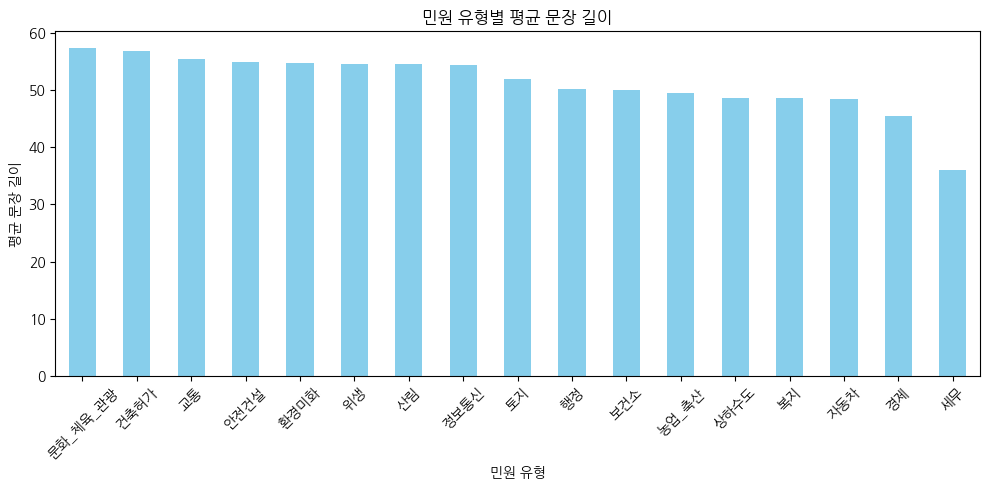

In [7]:
# 문장 길이 계산
df_sampled['text_len'] = df_sampled['text'].apply(len)

# 카테고리별 평균 문장 길이 계산
avg_length_by_category = df_sampled.groupby('category')['text_len'].mean().sort_values(ascending=False)

# 시각화
plt.figure(figsize=(10, 5))
avg_length_by_category.plot(kind='bar', color='skyblue')
plt.title('민원 유형별 평균 문장 길이')
plt.xlabel('민원 유형')
plt.ylabel('평균 문장 길이')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

민원 유형별 평균 문장 길이를 시각화해보면, `세무`를 제외하고는 민원 유형별 문장 길이가 크게 차이나진 않는 것을 볼 수 있습니다.

---

### 2.2. 민원 유형별 상위 10개 단어

다음으로는 민원 유형별로 가장 많이 등장하는 단어가 무엇인지 살펴보겠습니다.     
이때 텍스트 중에서 '명사'만을 추출하여 분석하는 것이 좋겠네요.     
이를 위해 **토크나이저(Tokenization)**를 활용합니다.     
토크나이저는 문장을 구성하는 단어, 구, 형태소 등으로 분해하는 작업을 수행하며, 자연어처리의 기본이 되는 첫 단계입니다.    

>📌`Okt`는 한국어 자연어 처리를 위한 형태소 분석기로, 입력된 문장을 품사 단위로 나누어 토큰화하는 도구입니다. 어간 추출, 정규화, 문장 분리 등의 기능을 제공하며, 특히 한국어의 복잡한 어순과 형태소 구조를 효과적으로 처리할 수 있다는 장점이 있습니다. 

먼저 `Okt`를 사용해 명사를 추출해 볼까요?      
`.nouns()`를 사용하면 명사만 추출할 수 있습니다.

In [8]:
# 명사 추출
from konlpy.tag import Okt

okt = Okt()
okt.nouns('경상남도 창원시 진해구 주소 생활 쓰레기 무단 불법 투기 신고입니다 과태료 징수 바랍니다')

['경상남도', '창원시', '진해구', '주소', '생활', '쓰레기', '무단', '불법', '투기', '신고', '과태료', '징수']

`.morphs()`를 사용하면 형태소 단위로 분리할 수 있습니다.

In [9]:
from konlpy.tag import Okt

okt = Okt()
okt.morphs('경상남도 창원시 진해구 주소 생활 쓰레기 무단 불법 투기 신고입니다 과태료 징수 바랍니다')

['경상남도',
 '창원시',
 '진해구',
 '주소',
 '생활',
 '쓰레기',
 '무단',
 '불법',
 '투기',
 '신고',
 '입니다',
 '과태료',
 '징수',
 '바랍니다']

그럼 이제 `Okt`를 사용하여 위 샘플 텍스트들에서 명사만 추출하고, 각 카테고리별 가장 많이 등장한 단어를 시각화해 보겠습니다.     
아래 코드를 통해 원본 텍스트에서 명사만 추출해 줍니다. 이 과정은 약 3분 정도 소요됩니다.

In [10]:
# 명사 추출 (약 3분 소요)
from tqdm import tqdm
tqdm.pandas()

def okt_tokenizer(text):
    return okt.nouns(text)

df_sampled['tokens'] = df_sampled['text'].progress_apply(okt_tokenizer)

100%|██████████| 16744/16744 [01:24<00:00, 199.10it/s]


In [11]:
df_sampled[['text', 'tokens']].head()

,text,tokens
0,공공기록물 관리에 관한 법률에 의거해 정보공개가 부존재한다면 언제 어떤 절차로 폐기...,"[기록물, 관리, 관, 법률, 의거, 정보공개, 부존재, 언제, 절차, 폐기]"
1,창원시 간판 인허가 문제로 할 말이 게 있습니다.,"[창원시, 간판, 인, 허가, 문제, 말, 게]"
2,마산합포구 #@주소# 중장비가 자주 다녀서 도로가 가라앉았습니다. 조치 바랍니다.,"[마산합포구, 주소, 중장비, 자주, 도로, 조치]"
3,불법 현수막 부착 신고합니다. 단속 해주세요.,"[불법, 현수막, 부착, 신고, 단속]"
4,마산합포구 #@주소# 외부벽 쪽인데 균열이 있어 위험하니 담당자는 현장 출동하여 정...,"[마산합포구, 주소, 외부, 벽, 쪽, 균열, 담당자, 현장, 출동, 정비]"


위와 같이 원본 텍스트에서 명사만 추출된 것을 확인할 수 있습니다.    
이 토큰들을 활용하여 민원 유형별 상위 10개 단어를 시각화해 봅시다.

/tmp/ipykernel_117/815905105.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', n_categories)


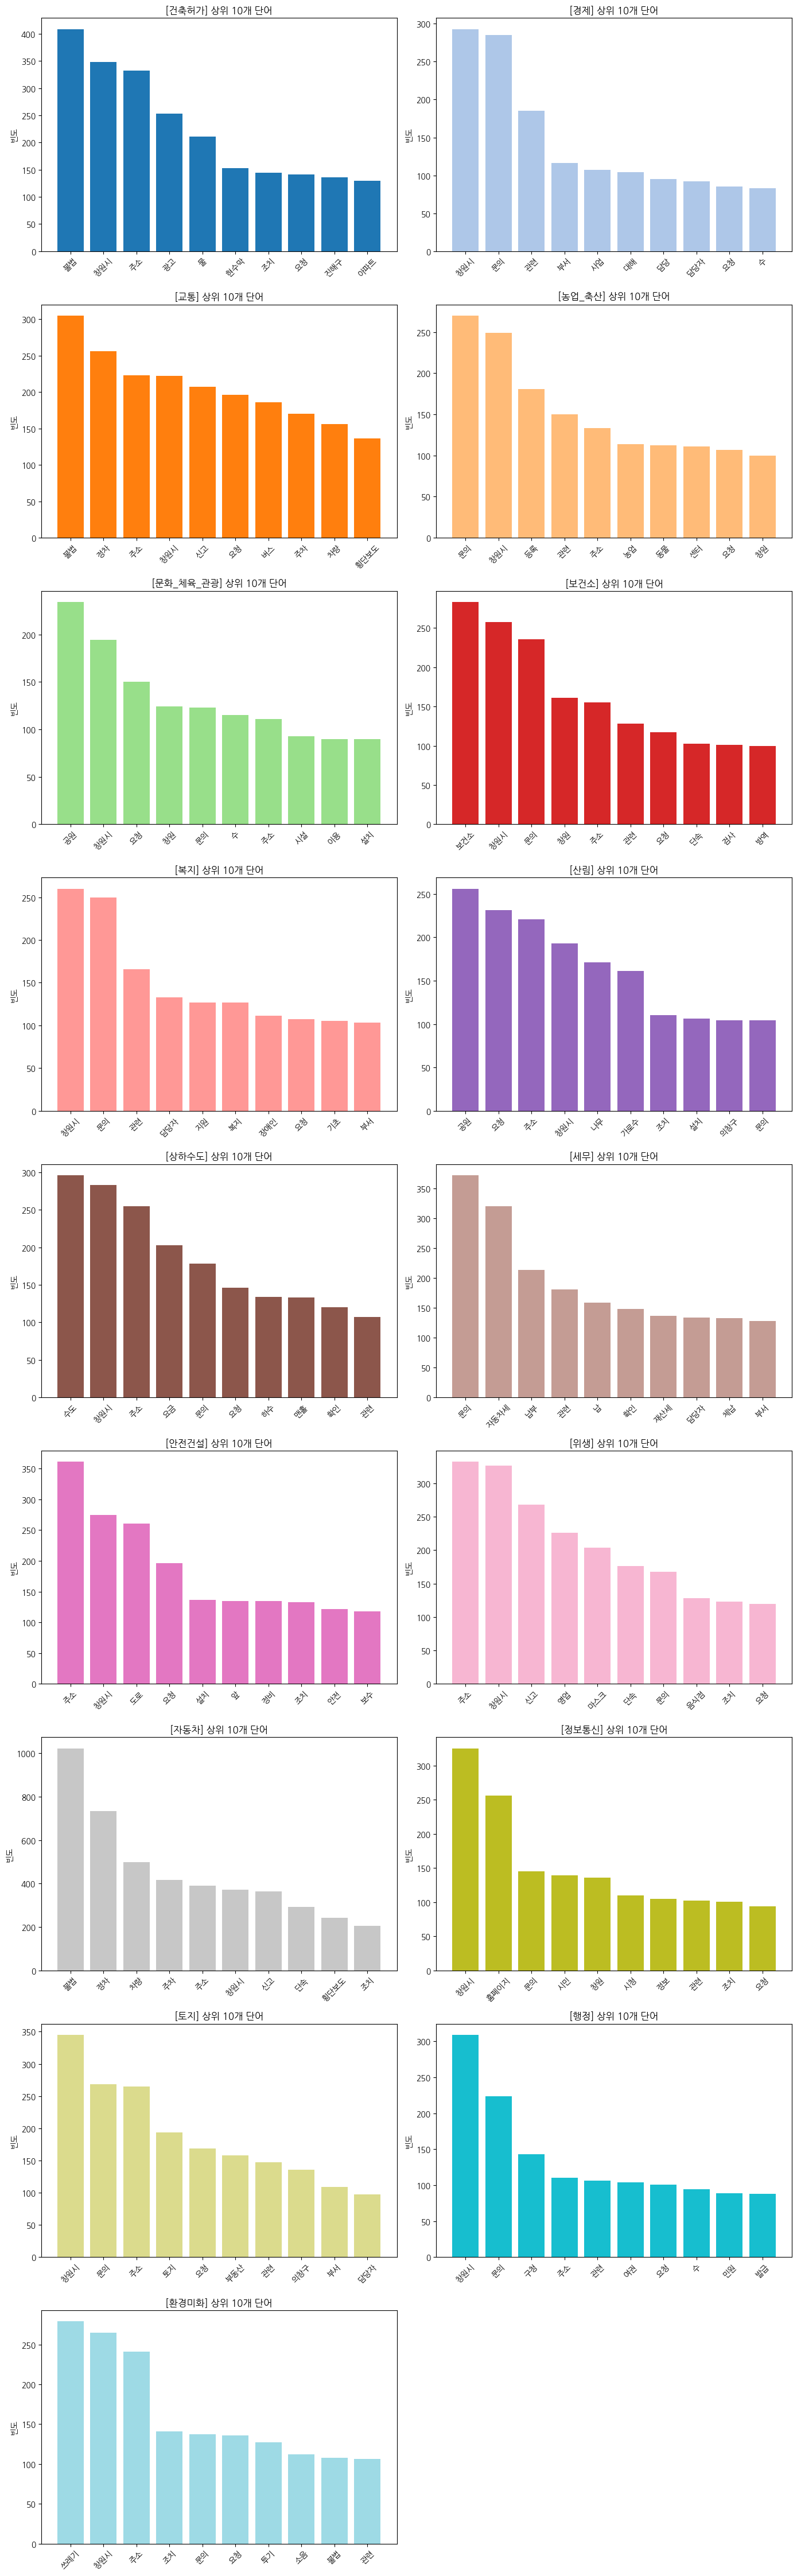

In [12]:
from collections import Counter

# 시각화 함수
def plot_top_words_subplots(df, category_col='category', token_col='tokens', top_n=10):
    grouped = df.groupby(category_col)
    n_categories = len(grouped)
    n_cols = 2
    n_rows = int(np.ceil(n_categories / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axs = axs.flatten()

    colors = cm.get_cmap('tab20', n_categories)

    for i, (category, group) in enumerate(grouped):
        all_tokens = sum(group[token_col], [])
        token_counts = Counter(all_tokens)
        most_common = token_counts.most_common(top_n)

        if not most_common:
            continue

        words, counts = zip(*most_common)

        axs[i].bar(words, counts, color=colors(i))
        axs[i].set_title(f"[{category}] 상위 {top_n}개 단어")
        axs[i].set_ylabel("빈도")
        axs[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

# 실행
plot_top_words_subplots(df_sampled)

결과를 살펴보면, 각 민원 유형별로 특징적인 단어들이 많이 등장하는 것을 알 수 있습니다.     
한편 `교통`과 `자동차` 유형의 경우는 상위 10개 단어가 많이 겹치네요. 이후 분류 모델을 만들 때 이 두 가지 유형의 분류 성능이 높지 않을 수도 있겠습니다.

---

## 3. 데이터 전처리

이번 챕터에서는 머신러닝 목적에 적합한 형태로 데이터를 전처리하는 실습을 진행하겠습니다.    
전처리 계획은 다음과 같습니다.     

> 독립변수
> - 민원 텍스트 TF-IDF 벡터화
>
> 종속변수
> - 민원 유형 라벨 인코딩

### 3.1. 민원 유형 라벨 인코딩

먼저 종속변수인 민원 유형을 라벨 인코딩하는 간단한 작업부터 진행해 봅시다.    
이번 학습에서는 전체 데이터에서 각 유형별로 최대 2000개의 샘플만 랜덤으로 뽑아 사용하겠습니다.

In [13]:
# 민원 유형별 최대 2000개 샘플 추출
df_sampled = df.groupby('category', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 2000), random_state=42))
df_sampled.reset_index(drop=True, inplace=True)
df_sampled

/tmp/ipykernel_117/2860904796.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('category', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 2000), random_state=42))


,text,category
0,공공기록물 관리에 관한 법률에 의거해 정보공개가 부존재한다면 언제 어떤 절차로 폐기...,건축허가
1,창원시 간판 인허가 문제로 할 말이 게 있습니다.,건축허가
2,마산합포구 #@주소# 중장비가 자주 다녀서 도로가 가라앉았습니다. 조치 바랍니다.,건축허가
3,불법 현수막 부착 신고합니다. 단속 해주세요.,건축허가
4,마산합포구 #@주소# 외부벽 쪽인데 균열이 있어 위험하니 담당자는 현장 출동하여 정...,건축허가
...,...,...
32739,"해운초등학교와 월영남 5길 사이의 길 쓰레기를 남의 집 앞이나 담벼락, 전봇대 옆에...",환경미화
32740,창원시 어제 올라온 환경미화원 채용 관련 공고문이 홈페이지 고시공고에서 검색이 안되...,환경미화
32741,경상남도 창원시 진해구 #@주소# 생활 쓰레기 무단 불법 투기 신고입니다. 과태료 ...,환경미화
32742,1시간 넘게 #@주소#에서 전차 주행 테스트를 하고 있습니다. 그런데 소음이 너무 ...,환경미화


이제 범주형 데이터를 숫자 라벨로 변환해 줍니다.

> 📌`LabelEncoder`는 범주형 문자열 데이터를 숫자형 라벨로 변환하여, 머신러닝 모델이 범주형 값을 처리할 수 있도록 합니다. 예를 들어, 클래스 레이블인 '교통', '건축허가가', '환경미화'를 각각 0, 1, 2와 같은 정수로 인코딩합니다.

In [14]:
from sklearn.preprocessing import LabelEncoder

# 라벨 인코딩
le = LabelEncoder()
df_sampled['label'] = le.fit_transform(df_sampled['category'])
df_sampled['label'].value_counts()

label
0     2000
1     2000
2     2000
3     2000
4     2000
5     2000
6     2000
7     2000
8     2000
9     2000
10    2000
11    2000
12    2000
14    2000
15    2000
16    2000
13     744
Name: count, dtype: int64

In [15]:
# 클래스 확인
le.classes_

array(['건축허가', '경제', '교통', '농업_축산', '문화_체육_관광', '보건소', '복지', '산림', '상하수도',
       '세무', '안전건설', '위생', '자동차', '정보통신', '토지', '행정', '환경미화'],
      dtype=object)

`LabelEncoder`가 학습한 고유 클래스들을 오름차순으로 나열해보면 다음과 같습니다.
- `건축허가` → `0`
- `경제` → `1`
- `교통` `2`
- ...


---

### 3.2. TF-IDF 벡터화

보통 머신러닝의 독립변수들은 센서 데이터 등 숫자로 이루어진 경우가 많은데요. 하지만 이번 프로젝트에서는 텍스트 데이터를 다루는 만큼 접근 방법이 조금 다릅니다.      
텍스트는 컴퓨터가 바로 이해할 수 없는 비정형 데이터이기 때문에, 먼저 이를 수치화하여 모델이 처리할 수 있는 형태로 변환해줘야 합니다.    
이 과정에서 가장 널리 사용되는 기법 중 하나가 바로 **TF-IDF(Term Frequency-Inverse Document Frequency)**입니다.


> 📌`TF-IDF`는 각 단어가 문서 내에서 얼마나 중요한지를 수치로 나타내는 방법입니다. 이때 단순히 단어가 자주 등장한다고 중요한 것은 아닙니다. 예를 들어, “신고”, “요청” 같은 단어는 거의 모든 문서에서 등장할 수 있는데, 이런 단어들에 높은 가중치를 주면 오히려 문서의 특성을 잘 반영하지 못하게 됩니다.
> 이를 해결하기 위해 TF-IDF는 두 가지 요소를 결합합니다:
> - `TF(Term Frequency)`: 특정 단어가 문서 내에 얼마나 자주 등장했는지를 나타냅니다. 자주 등장할수록 해당 문서에서 중요한 단어일 가능성이 높다고 가정합니다.
> - `IDF(Inverse Document Frequency)`: 전체 문서 집합 중에서 특정 단어가 등장한 문서의 비율을 반영합니다. 많은 문서에서 공통적으로 등장하는 단어일수록 그 중요도를 낮게 평가합니다.

즉, TF-IDF는 문서 내부에서 자주 등장하지만 전체 문서에서는 드물게 나타나는 단어에 높은 가중치를 부여합니다.    
TF-IDF를 사용해 텍스트 데이터를 벡터 형태로 변환하면, 비로소 머신러닝 모델이 텍스트를 숫자로 표현된 특성(Feature)으로 인식할 수 있게 되어 수치적인 계산이 가능해집니다.

예를 들어 다음과 같은 3개의 문서가 있을 떄, 이를 TF-IDF 벡터로 표현해 볼까요?
- Sentence 1: "The cat meows loudly"
- Sentence 2: "The dog barks loudly"
- Sentence 3: "The cat and dog play together"

In [16]:
docs = [
    "The cat meows loudly",
    "The dog barks loudly",
    "The cat and dog play together"
]

`TfidfVectorizer`를 통해 문서를 벡터화할 수 있습니다.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(docs)
tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14 stored elements and shape (3, 9)>

예시 문장들에 대한 TF-IDF를 확인해 봅시다.

In [18]:
tfidf_df = pd.DataFrame(
    tfidf.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f"Sentence {i+1}" for i in range(len(docs))]
)
tfidf_df

,and,barks,cat,dog,loudly,meows,play,the,together
Sentence 1,0.00000,0.000000,0.480458,0.000000,0.480458,0.631745,0.00000,0.373119,0.00000
Sentence 2,0.00000,0.631745,0.000000,0.480458,0.480458,0.000000,0.00000,0.373119,0.00000
Sentence 3,0.47111,0.000000,0.358291,0.358291,0.000000,0.000000,0.47111,0.278245,0.47111


위와 같이 TF-IDF는 문서들의 핵심 단어를 수치화해 표현함으로써, 머신러닝 모델이 텍스트 데이터를 효과적으로 이해하고 분류할 수 있도록 돕는 전처리 기법입니다.

그럼 이제 본격적으로 학습 데이터셋에 대해서도 TF-IDF를 만들어 볼까요?     
우선 불필요한 단어나 기호들을 제거하겠습니다.

In [19]:
import re

def clean_text(text):
    # 2. 한글, 영어, 숫자, 공백만 남기기
    text = re.sub(r"[^가-힣a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text 

In [20]:
df_sampled['clean_text'] = df_sampled['text'].apply(clean_text)
df_sampled['clean_text']

0        공공기록물 관리에 관한 법률에 의거해 정보공개가 부존재한다면 언제 어떤 절차로 폐기...
1                               창원시 간판 인허가 문제로 할 말이 게 있습니다
2                 마산합포구 주소 중장비가 자주 다녀서 도로가 가라앉았습니다 조치 바랍니다
3                                  불법 현수막 부착 신고합니다 단속 해주세요
4        마산합포구 주소 외부벽 쪽인데 균열이 있어 위험하니 담당자는 현장 출동하여 정비 바랍니다
                               ...                        
32739    해운초등학교와 월영남 길 사이의 길 쓰레기를 남의 집 앞이나 담벼락 전봇대 옆에 함...
32740    창원시 어제 올라온 환경미화원 채용 관련 공고문이 홈페이지 고시공고에서 검색이 안되...
32741    경상남도 창원시 진해구 주소 생활 쓰레기 무단 불법 투기 신고입니다 과태료 징수 바랍니다
32742    시간 넘게 주소에서 전차 주행 테스트를 하고 있습니다 그런데 소음이 너무 큽니다 저...
32743                진해구 주소 앞에 폐가구가 버려져 있어 지저분하니 빨리 치워 주세요
Name: clean_text, Length: 32744, dtype: object

이번엔 훈련 및 테스트 데이터를 구분하겠습니다. 

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_sampled['clean_text'], df_sampled['label'], test_size=0.2, random_state=42)

In [22]:
X_train

28571                        진해구 소재 토지등급은 어디로 확인해야 알 수 있나요
15035    남산배드민턴장 주변 잡초가 많아 벌레가 많이 있으니 주변 잡초를 제거 및 배드민턴장...
11057                             창원시 어린이 예방접종 담당자를 연결해주세요
31214                                   창원시 쓰레기 불법투기 신고합니다
15073                         용지호수공원 음악분수 운영기간과 공연시간 알려주세요
                               ...                        
29802                   가족관계증명서 정정접수 처리완료 확인 관련 창원시에 문의합니다
5390                       마산회원구 석전동 기타 불법주정차 불법 주정차 신고입니다
860                               도로 위 불법 광고물 확인 후 조치해 주세요
15795                             창원시의 가로수 쓰러져 가는 거 처리해주세요
23654               도계동 소재 체력단련장 마스크 착용 불량자들 단속 해주시길 요청합니다
Name: clean_text, Length: 26195, dtype: object

In [23]:
y_train

28571    14
15035     7
11057     5
31214    16
15073     7
         ..
29802    15
5390      2
860       0
15795     7
23654    11
Name: label, Length: 26195, dtype: int64

자, 이제 `TfidfVectorizer`를 사용하여 학습 및 테스트 데이터를 벡터화할 차례입니다.      
이때 `tokenizer`를 앞서 살펴본 `okt.nouns()`로 설정하여 명사만 가지고 TF-IDF를 만들도록 합니다.

In [24]:
def okt_tokenizer(text):
    return okt.nouns(text)

vectorizer = TfidfVectorizer(tokenizer=okt_tokenizer)

In [25]:
# 약 3분 소요
X_train_tfidf = vectorizer.fit_transform(X_train) 
X_test_tfidf = vectorizer.transform(X_test)

/home/elicer/.local/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [26]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 262126 stored elements and shape (26195, 11143)>

TF-IDF가 잘 완성되었는지 확인해 볼까요?

In [27]:
feature_names = vectorizer.get_feature_names_out()
dense_tfidf = X_train_tfidf.toarray()
tfidf_df = pd.DataFrame(dense_tfidf, columns=feature_names)
tfidf_df.index = [f'doc{i+1}' for i in range(tfidf_df.shape[0])]

# 상위 5개 확인
tfidf_df.head()

,가,가가,가건물,가게,가격,가격담합,가격표,가계비,가계약,가공,...,히어로즈,힌,힐,힐링,힐링캠프,힐스,힐스테이트,힐차,힘,힙
doc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
doc2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
doc3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
doc4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
doc5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TF-IDF가 벡터라면, 같은 클래스의 텍스트는 서로 유사한 방향을 가질 가능성이 높습니다.     
실제로 이러한 경향이 있는지, 간단한 시각화를 통해 확인해보겠습니다.     
여기서는 편의를 위해 2000개 샘플만 추출하고 차원도 크게 축소시켰습니다.

> 📌`t-SNE(t-Distributed Stochastic Neighbor Embedding)`는 고차원 데이터를 2차원 또는 3차원으로 시각화할 수 있도록 차원을 축소해주는 비선형 차원 축소 기법입니다.     데이터 간 이웃 관계를 잘 보존하며, 복잡한 데이터의 숨겨진 패턴이나 군집 구조를 시각적으로 이해하는 데 유용합니다.

In [28]:
# 전체 데이터에서 2000개 샘플만, 클래스 비율을 유지하며 추출
X_sampled_tfidf, _, y_sampled, _ = train_test_split(
    X_train_tfidf, y_train,
    train_size=2000,
    stratify=y_train,
    random_state=42
)

/home/elicer/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


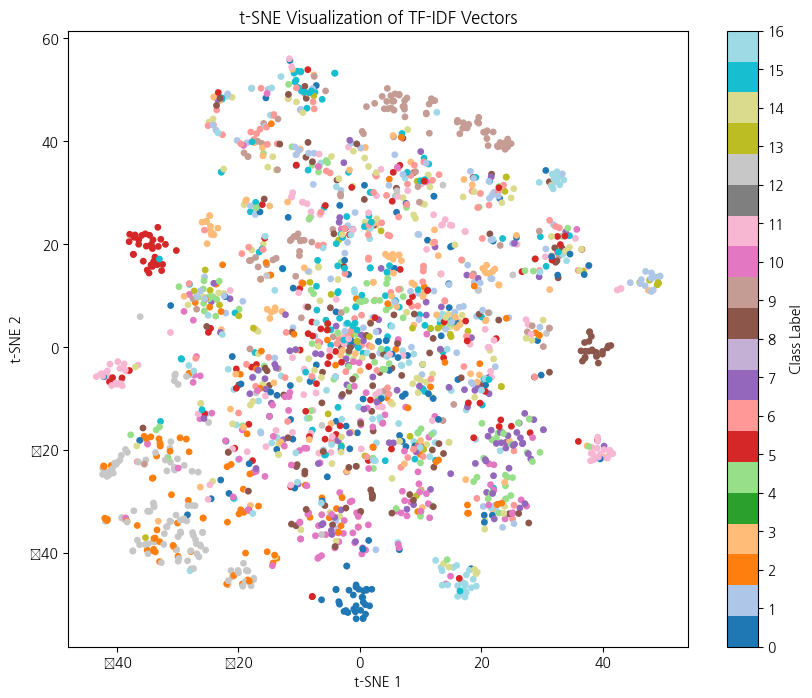

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 차원 축소
X_reduced = PCA(n_components=50).fit_transform(X_sampled_tfidf)
tsne = TSNE(n_components=2, init='random', random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_reduced)

# 시각화
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sampled, cmap='tab20', s=15)
plt.title("t-SNE Visualization of TF-IDF Vectors")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(scatter, ticks=range(17), label="Class Label")
plt.show()

시각화 결과를 보면, 같은 민원 유형의 텍스트 벡터들이 비교적 모여있는 경향을 보이는 것을 확인할 수 있습니다.

### <span style="font-size:24px">[TODO] TF-IDF 벡터화</span>

- 목표: 주어진 예시 문서들에 대해 TF-IDF 벡터화
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: 형태소 단위로 분리하는 토크나이저를 적용해 TF-IDF를 정확하게 생성한 경우 통과
    - 정답과 동일한 차원 및 값을 가지는 TF-IDF 벡터가 출력되어야 함

In [30]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import json

okt = Okt()

docs = [
    "나는 오늘 아침에 커피를 마셨다.",
    "아침 식사는 빵과 커피였다.",
    "저녁에는 친구들과 영화를 봤다.",
    "나는 커피보다 차를 좋아한다.",
    "친구와 함께 아침 운동을 했다."
]

def okt_tokenizer(text):
    return okt.morphs(text)

vectorizer = TfidfVectorizer(tokenizer=okt_tokenizer)

docs_tfidf = vectorizer.fit_transform(docs)

feature_names = vectorizer.get_feature_names_out()
dense_tfidf = docs_tfidf.toarray()
tfidf_df = pd.DataFrame(dense_tfidf, columns=feature_names)
tfidf_df.index = [f'doc{i+1}' for i in range(tfidf_df.shape[0])]
tfidf_df_todo1 = tfidf_df.to_json()
tfidf_df_todo1 = json.loads(tfidf_df_todo1)
tfidf_df

/home/elicer/.local/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,.,과,나,는,들,를,마셨다,보다,봤다,빵,...,와,운동,을,저녁,좋아한다,차,친구,커피,함께,했다
doc1,0.200078,0.000000,0.338761,0.281202,0.000000,0.281202,0.419885,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.281202,0.000000,0.000000
doc2,0.208491,0.353005,0.000000,0.293026,0.000000,0.000000,0.000000,0.000000,0.000000,0.437541,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.293026,0.000000,0.000000
doc3,0.180393,0.305433,0.000000,0.000000,0.378576,0.253537,0.000000,0.000000,0.378576,0.000000,...,0.000000,0.000000,0.000000,0.378576,0.000000,0.000000,0.305433,0.000000,0.000000,0.000000
doc4,0.208491,0.000000,0.353005,0.293026,0.000000,0.293026,0.000000,0.437541,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.437541,0.437541,0.000000,0.293026,0.000000,0.000000
doc5,0.189446,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.397575,0.397575,0.397575,0.000000,0.000000,0.000000,0.320761,0.000000,0.397575,0.397575


---

## 4. 민원 유형 텍스트 분류 모델

이번 챕터에서는 민원 텍스트 데이터를 바탕으로 민원 유형을 분류하는 모델을 실습해 보겠습니다.

평가 지표는 다음과 같습니다.

> Confusion Matrix (혼동행렬)    
> - 실제 클래스와 예측 클래스의 분포를 행렬로 나타낸 것으로, True Positive, True Negative, False Positive, False Negative의 수를 통해 모델의 예측 성능을 구체적으로 파악할 수 있습니다.
>
> Classification Report
> - `Accuracy`: 전체 예측 중 맞춘 비율을 의미하며, 값이 높을수록 모델의 전반적인 예측 성능이 좋습니다.
>
> - `Precision`: 양성으로 예측한 것 중 실제로 양성인 비율로, 값이 높을수록 거짓 양성(False Positive)이 적음을 의미합니다.
>
> - `Recall`: 실제 양성 중 모델이 양성으로 맞게 예측한 비율로, 값이 높을수록 거짓 음성(False Negative)이 적음을 의미합니다.
>
> - `F1-score`: Precision과 Recall의 조화 평균으로, 두 지표의 균형을 평가하며 값이 높을수록 모델이 안정적으로 잘 예측했음을 의미합니다.
> 
> - `Macro avg`: 클래스별 지표의 단순 평균으로, 각 클래스의 중요도를 동일하게 평가하며 값이 높을수록 전반적인 균형 잡힌 성능을 의미합니다.
> 
> - `Weighted avg`: 클래스별 지표를 각 클래스의 샘플 수로 가중 평균한 값으로, 값이 높을수록 전체 데이터 분포를 고려했을 때 모델 성능이 우수함을 의미합니다.

### 4.1. KNeighborsClassifier

> 📌 `KNeighborsClassifier`(KNN)은 예측하려는 데이터 포인트 주변의 가장 가까운 K개의 이웃 데이터를 참조하여 분류를 수행합니다.     
거리 기반으로 작동하며, 사전에 학습된 모델이 아닌 데이터를 저장하고 예측 시 계산하는 Lazy Learning 방식입니다.     
단순하고 직관적이지만, 고차원 데이터에서는 성능이 저하될 수 있고 예측 속도가 느릴 수 있다는 단점이 있습니다.

In [31]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 모델 정의 및 학습
knn_clf = KNeighborsClassifier(n_neighbors=17)
knn_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = knn_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        건축허가       0.61      0.62      0.61       364
          경제       0.65      0.68      0.66       409
          교통       0.56      0.45      0.50       401
       농업_축산       0.78      0.83      0.81       387
    문화_체육_관광       0.55      0.60      0.57       413
         보건소       0.71      0.76      0.73       415
          복지       0.74      0.67      0.70       398
          산림       0.69      0.51      0.59       412
        상하수도       0.79      0.82      0.80       389
          세무       0.81      0.88      0.84       417
        안전건설       0.60      0.56      0.58       403
          위생       0.70      0.74      0.72       371
         자동차       0.61      0.91      0.73       415
        정보통신       0.69      0.65      0.67       144
          토지       0.67      0.61      0.64       399
          행정       0.56      0.47      0.51       408
        환경미화       0.74      0.67      0.70       404

    accuracy              

분류 결과를 보면 Weighted F1이 0.67로, 성능이 크게 높진 않네요.

---

### 4.2. MultinomialNB

> 📌 `MultinomialNB`는 나이브 베이즈(Naive Bayes) 알고리즘 중 하나로, 문서 분류나 스팸 필터링 등 이산적인 특성(특히 단어의 등장 횟수)에 적합한 확률 기반의 지도학습 분류 모델입니다.     
각 클래스에 대해 단어의 출현 확률 분포를 학습하고, 베이즈 정리를 이용해 가장 확률이 높은 클래스를 예측합니다.

In [32]:
from sklearn.naive_bayes import MultinomialNB

# 모델 정의 및 학습
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = nb_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        건축허가       0.63      0.63      0.63       364
          경제       0.72      0.69      0.71       409
          교통       0.58      0.40      0.48       401
       농업_축산       0.87      0.83      0.85       387
    문화_체육_관광       0.61      0.62      0.61       413
         보건소       0.84      0.70      0.76       415
          복지       0.76      0.73      0.75       398
          산림       0.66      0.62      0.64       412
        상하수도       0.80      0.84      0.82       389
          세무       0.86      0.92      0.89       417
        안전건설       0.53      0.62      0.57       403
          위생       0.67      0.84      0.74       371
         자동차       0.69      0.87      0.77       415
        정보통신       0.96      0.35      0.51       144
          토지       0.64      0.73      0.68       399
          행정       0.56      0.53      0.55       408
        환경미화       0.73      0.75      0.74       404

    accuracy              

분류 결과를 보면, 앞서 `KNeighborsClassifier`를 사용한 경우보다 더 높은 성능을 보이고 있습니다.

---

### 4.3. LinearSVC

> 📌`LinearSVC`는 선형 서포트 벡터 머신(SVM, Support Vector Machine)을 사용한 지도학습 분류 모델로, 대규모 고차원 데이터에 적합한 선형 결정 경계를 학습합니다.     
입력 특성과 출력 클래스 사이의 선형 관계를 기반으로 하며, 마진(margin)을 최대화하는 초평면을 찾아 분류 성능을 높입니다. 

In [33]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# 모델 정의 및 학습
svm_clf = LinearSVC(random_state=42)
svm_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = svm_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        건축허가       0.69      0.65      0.67       364
          경제       0.76      0.78      0.77       409
          교통       0.60      0.53      0.56       401
       농업_축산       0.87      0.89      0.88       387
    문화_체육_관광       0.66      0.66      0.66       413
         보건소       0.82      0.79      0.81       415
          복지       0.75      0.77      0.76       398
          산림       0.69      0.64      0.66       412
        상하수도       0.86      0.90      0.88       389
          세무       0.94      0.90      0.92       417
        안전건설       0.59      0.63      0.61       403
          위생       0.74      0.79      0.77       371
         자동차       0.76      0.85      0.80       415
        정보통신       0.82      0.90      0.86       144
          토지       0.72      0.76      0.74       399
          행정       0.63      0.58      0.60       408
        환경미화       0.77      0.75      0.76       404

    accuracy              

`LinearSVC`를 사용하였을 때, 앞서 두 모델보다 Weighted F1이 더 높아진 것을 확인할 수 있습니다.

---

### 4.4. RandomForestClassifier

> 📌 `RandomForestClassifier`는 여러 개의 의사결정트리를 랜덤하게 만들어 학습하고, 그 예측 결과를 투표 방식으로 결합해 최종 분류를 수행하는 앙상블 학습 모델입니다.    
데이터 샘플과 특성을 무작위로 선택해 각 트리를 구성함으로써 편향은 낮추고, 분산을 줄여 과적합을 방지합니다.    
높은 예측 성능과 안정성, 그리고 feature importance 분석 기능이 주요 장점입니다.

In [34]:
from sklearn.ensemble import RandomForestClassifier

# 모델 정의 및 학습
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = rf_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        건축허가       0.66      0.67      0.66       364
          경제       0.70      0.72      0.71       409
          교통       0.61      0.52      0.56       401
       농업_축산       0.85      0.83      0.84       387
    문화_체육_관광       0.65      0.65      0.65       413
         보건소       0.83      0.73      0.78       415
          복지       0.74      0.70      0.72       398
          산림       0.71      0.59      0.64       412
        상하수도       0.84      0.84      0.84       389
          세무       0.94      0.90      0.92       417
        안전건설       0.53      0.61      0.56       403
          위생       0.69      0.82      0.75       371
         자동차       0.77      0.87      0.82       415
        정보통신       0.88      0.90      0.89       144
          토지       0.78      0.79      0.78       399
          행정       0.57      0.61      0.59       408
        환경미화       0.80      0.78      0.79       404

    accuracy              

분류 결과를 보면 `LinearSVC`와 비슷한 수준의 성능을 보여주네요.

---

### 4.5. XGBClassifier

> 📌 `XGBClassifier`는 Gradient Boosting 기반의 고성능 분류 모델로, 여러 약한 학습기를 순차적으로 학습시키며 이전 모델의 오류를 보완해 예측 성능을 점점 향상시키는 방식입니다. 정확도와 속도 면에서 매우 우수하며, 대규모 데이터나 실무 환경에서도 널리 사용됩니다.     
> 여러 결정트리를 무작위로 학습시켜 그 결과를 평균 또는 다수결로 결정하는 Bagging 방식의 `RandomForestClassifier`와 달리, `XGBClassifier`는 Boosting 방식으로 각 모델이 순차적으로 학습되고, 이전 모델의 오류를 반영하여 다음 모델을 개선하는 구조를 가집니다.

In [35]:
from xgboost import XGBClassifier

# 모델 정의 및 학습
xgb_clf = XGBClassifier(
    n_estimators=200, 
    max_depth=5,
    learning_rate=0.3,
    reg_lambda=1,
    random_state=42)
xgb_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = xgb_clf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        건축허가       0.64      0.67      0.66       364
          경제       0.75      0.72      0.73       409
          교통       0.59      0.53      0.56       401
       농업_축산       0.88      0.82      0.85       387
    문화_체육_관광       0.64      0.66      0.65       413
         보건소       0.81      0.74      0.78       415
          복지       0.74      0.70      0.72       398
          산림       0.70      0.59      0.64       412
        상하수도       0.90      0.88      0.89       389
          세무       0.95      0.89      0.92       417
        안전건설       0.55      0.63      0.59       403
          위생       0.72      0.77      0.74       371
         자동차       0.79      0.86      0.82       415
        정보통신       0.79      0.80      0.79       144
          토지       0.73      0.71      0.72       399
          행정       0.50      0.62      0.55       408
        환경미화       0.77      0.77      0.77       404

    accuracy              

`XGBClassifier`의 분류 성능은 앞서 `RandomForestClassifier`와 비슷합니다.    
그럼 이번엔 `XGBClassifier` 학습 파라미터들을 직접 조정해보며 성능 변화를 탐색해 볼까요?

### <span style="font-size:24px">[TODO] XGBClassifier 학습</span>

- 목표: XGBClassifier 모델 학습 및 평가
- 수행 방법: 아래 코드에서 `[TODO]`로 표시된 빈칸들을 작성해세요.
- 채점: 파라미터를 조절하며 모델을 학습 및 평가하고, weighted f1-score가 일정 수치 이상인 경우 통과
    - weighted avg: 0.70 이상인 경우 통과

In [36]:
xgb_clf_todo = XGBClassifier(
    #################################### 
    # [TODO] 모델 학습 파라미터를 작성하세요.
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
    ###################################   
)

#################################### 
# [TODO] 모델 학습 코드를 작성하세요.
xgb_clf_todo.fit(X_train_tfidf, y_train)
####################################

#################################### 
# [TODO] 모델 평가 코드를 작성하세요.
y_pred_todo2 = xgb_clf_todo.predict(X_test_tfidf)

classification_report_todo2 = classification_report(y_test, y_pred_todo2, target_names=le.classes_, output_dict=True)
####################################

print("XGB Classifier")
print()
print(f"Weighted F1: {classification_report_todo2['weighted avg']['f1-score']}")

XGB Classifier

Weighted F1: 0.7127953034365508


---

### 4.6. Ensemble

마지막으로, 앞서 성능이 좋았던 모델들인 `LinearSVC`, `RandomForestClassifier`, `XGBClassifier`를 결합하는 앙상블 모델을 만들어 보겠습니다.

> 📌`VotingClassifier`는 여러 개의 서로 다른 분류 모델을 결합하여 예측을 수행하는 앙상블 학습 방법입니다. 각 개별 모델의 예측 결과를 모아서 투표를 통해 최종 예측을 결정합니다.
> - 하드 보팅(Hard Voting): 각 모델이 예측한 클래스 중 다수결로 최종 클래스를 선택합니다.
> - 소프트 보팅(Soft Voting): 각 모델이 예측한 클래스의 확률을 평균내어 가장 높은 확률을 가진 클래스를 선택합니다.     
>
> 여러 모델의 장점을 결합하여 단일 모델보다 더 안정적이고 일반화된 예측 성능을 낼 수 있다는 장점이 있습니다. 단, 구성하는 모델 수가 많아질수록 학습과 예측 시간이 증가할 수 있으며, 모델 간의 성능 균형과 조합에 따라 결과가 달라질 수 있습니다.

In [37]:
from sklearn.ensemble import VotingClassifier

# 앙상블 모델 구성 및 학습
ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_clf), ('xgb', xgb_clf), ('svm', svm_clf)],
    voting='hard',
    n_jobs=-1
)
ensemble_clf.fit(X_train_tfidf, y_train)

# 예측 및 평가
y_pred = ensemble_clf.predict(X_test_tfidf)

print("Ensemble")
print()
print("Classification Report\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Ensemble

Classification Report

              precision    recall  f1-score   support

        건축허가       0.63      0.71      0.67       364
          경제       0.72      0.78      0.74       409
          교통       0.60      0.56      0.58       401
       농업_축산       0.88      0.88      0.88       387
    문화_체육_관광       0.66      0.69      0.67       413
         보건소       0.84      0.79      0.81       415
          복지       0.77      0.73      0.75       398
          산림       0.74      0.60      0.67       412
        상하수도       0.90      0.89      0.89       389
          세무       0.94      0.90      0.92       417
        안전건설       0.60      0.63      0.62       403
          위생       0.74      0.81      0.77       371
         자동차       0.79      0.87      0.83       415
        정보통신       0.86      0.92      0.89       144
          토지       0.78      0.77      0.77       399
          행정       0.62      0.61      0.62       408
        환경미화       0.81      0.79      0.80     

앙상블 모델의 결과를 살펴보면 Weighted F1이 0.75로, 3개의 개별적인 모델보다 성능이 나아진 것을 확인할 수 있습니다.

---

## <span style="font-size:24px">[TODO] 실습 결과 제출</span>


실습 중간 `[TODO]` 코드들을 모두 잘 작성하셨나요?     
아래 코드를 실행 후, 오른쪽 상단의 제출 버튼을 클릭해 주세요.

🟨 **주의 사항**
- 아래 코드를 실행하기 전 `[TODO]` 빈칸을 모두 잘 작성하였는지, 통과 조건을 만족하였는지 반드시 확인해 주세요.
- `[TODO]`에서 지정된 변수명이나 아래 코드를 임의로 수정할 경우, 채점이 제대로 이루어지지 않을 수 있습니다.

In [38]:
import json

student_answers = {}
student_answers["tfidf_df_todo1"] = dict(tfidf_df_todo1)
student_answers["classification_report_todo2"] = dict(classification_report_todo2)

with open("result.json", "w") as f:
    json.dump(student_answers, f)